In [30]:
!pip install wordcloud

     -------------------------------------- 300.0/300.0 kB 2.1 MB/s eta 0:00:00


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
true_path = 'True.csv'
fake_path = 'Fake.csv'

true_df = pd.read_csv(true_path)
fake_df = pd.read_csv(fake_path)

In [34]:
true_df['true'] = 1
fake_df['true'] = 0

df = pd.concat([true_df, fake_df])
display(df)

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [35]:
true_counts = df['true'].value_counts()

print("Number of Total True News:", true_counts[1])
print("Number of Total Fake news:", true_counts[0])

Number of Total True News: 21417
Number of Total Fake news: 23481


In [36]:
df.drop_duplicates()
df.dropna()

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [37]:
df.drop(columns = ["text","subject","date"])

,title,true
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1
...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,0
23479,How to Blow $700 Million: Al Jazeera America F...,0


In [38]:
from sklearn.utils import shuffle

df = df.iloc[:,[0,-1]]
df = df.sample(frac=1).reset_index(drop=True)
display(df)

,title,true
0,GREAT! See What Trump Did When He Was Told The...,0
1,Hell Comes to Frogtown: Alt Right and Triumph ...,0
2,Uganda's president boosts military unit as rur...,1
3,RUBIO DOUBLES DOWN ON Putting Illegal Aliens B...,0
4,"Myanmar faces 'defining moment', must stop the...",1
...,...,...
44893,STUDENT NEWSPAPER At Hillary’s Alma Mater: It’...,0
44894,Factbox: What do the new U.S. sanctions on Rus...,1
44895,Philadelphia Fox affiliate suspends TV host fo...,1
44896,DEATH AND TAXES: Over Half Of Prince’s Estate ...,0


In [39]:
df['title'] = (df['title'].str.lower())
print(df)

                                                   title  true
0      great! see what trump did when he was told the...     0
1      hell comes to frogtown: alt right and triumph ...     0
2      uganda's president boosts military unit as rur...     1
3      rubio doubles down on putting illegal aliens b...     0
4      myanmar faces 'defining moment', must stop the...     1
...                                                  ...   ...
44893  student newspaper at hillary’s alma mater: it’...     0
44894  factbox: what do the new u.s. sanctions on rus...     1
44895  philadelphia fox affiliate suspends tv host fo...     1
44896  death and taxes: over half of prince’s estate ...     0
44897      obama briefed after britain votes to leave eu     1

[44898 rows x 2 columns]


In [40]:
df['title'] = df['title'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
df.head()

,title,true
0,great! see what trump did when he was told the...,0
1,hell comes to frogtown: alt right and triumph ...,0
2,uganda's president boosts military unit as rur...,1
3,rubio doubles down on putting illegal aliens b...,0
4,"myanmar faces 'defining moment', must stop the...",1


In [41]:
df['title'] = df['title'].str.replace(r"[\"\'\|\?\=\.\<\>\@\#\*\,]", '')
df.head()

,title,true
0,great! see what trump did when he was told the...,0
1,hell comes to frogtown: alt right and triumph ...,0
2,ugandas president boosts military unit as rura...,1
3,rubio doubles down on putting illegal aliens b...,0
4,myanmar faces defining moment must stop the vi...,1


In [42]:
def tokenize(txt):
    tokens = re.split('\W+', txt)
    return tokens

In [43]:
df['title'] = df['title'].apply(lambda x: tokenize(x.lower()))
df.head()

,title,true
0,"[great, see, what, trump, did, when, he, was, ...",0
1,"[hell, comes, to, frogtown, alt, right, and, t...",0
2,"[ugandas, president, boosts, military, unit, a...",1
3,"[rubio, doubles, down, on, putting, illegal, a...",0
4,"[myanmar, faces, defining, moment, must, stop,...",1


In [44]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [45]:
def remove_punctuation(txt):
    txt_nopunct = " ".join([c for c in txt if c not in string.punctuation])
    return txt_nopunct

In [46]:
df['title'] = df['title'].apply(lambda x : remove_punctuation(x))
df.head()

,title,true
0,great see what trump did when he was told ther...,0
1,hell comes to frogtown alt right and triumph o...,0
2,ugandas president boosts military unit as rura...,1
3,rubio doubles down on putting illegal aliens b...,0
4,myanmar faces defining moment must stop the vi...,1


In [47]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
from nltk.corpus import stopwords

In [49]:
",".join(stopwords.words('english'))

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

In [50]:
stop_words = set(stopwords.words('english'))

In [51]:
def remove_stop(x):
    return ",".join([word for word in str(x).split() if word not in stop_words])

In [52]:
df['title'] = df['title'].apply(lambda x : remove_stop(x))
df.head()

,title,true
0,"great,see,trump,told,time,sing,national,anthem...",0
1,"hell,comes,frogtown,alt,right,triumph,transhum...",0
2,"ugandas,president,boosts,military,unit,rural,s...",1
3,"rubio,doubles,putting,illegal,aliens,americans",0
4,"myanmar,faces,defining,moment,must,stop,violen...",1


In [53]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [54]:
lemmatizer = WordNetLemmatizer()

In [55]:
def data_processing(data):
    data = [lemmatizer.lemmatize(word) for word in data]
    data = ''.join(data)
    return data

In [56]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [57]:
df['title'] = df['title'].apply(lambda data: data_processing(data))
df.head()

,title,true
0,"great,see,trump,told,time,sing,national,anthem...",0
1,"hell,comes,frogtown,alt,right,triumph,transhum...",0
2,"ugandas,president,boosts,military,unit,rural,s...",1
3,"rubio,doubles,putting,illegal,aliens,americans",0
4,"myanmar,faces,defining,moment,must,stop,violen...",1


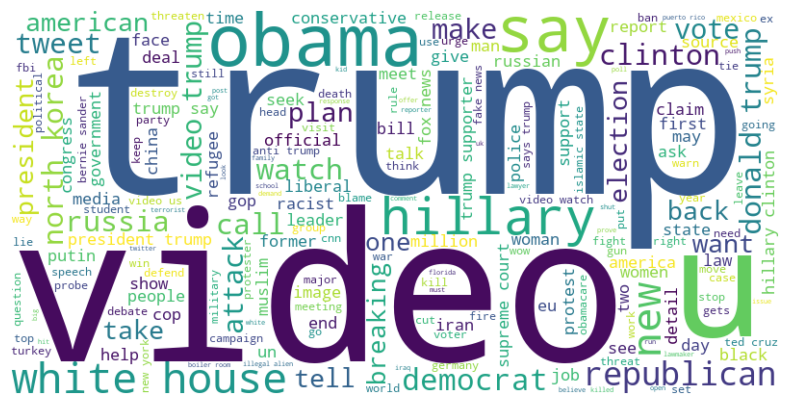

In [62]:
from wordcloud import WordCloud

text = ' '.join(df['title'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()